In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread("../data/images/neonlady.png")

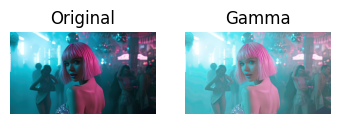

In [3]:
gamma = 0.4
lookUpTable = np.empty((1, 256), np.uint8)
for i in range(256):
    lookUpTable[0, i] = np.clip(pow(i / 255, gamma) * 255.0, 0 ,255)

output_image = cv2.LUT(image, lookUpTable)

plt.subplot(231)
plt.imshow(image[..., ::-1])
plt.title("Original")
plt.axis("off")

plt.subplot(232)
plt.imshow(output_image[..., ::-1])
plt.title("Gamma")
plt.axis("off")

plt.show();

127.0


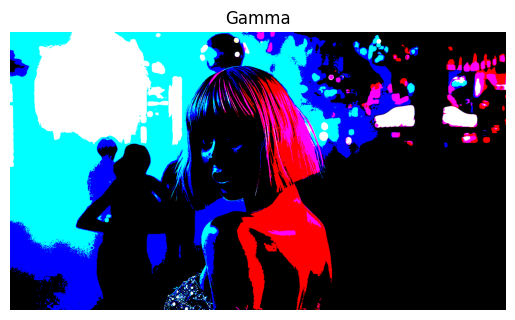

In [4]:
ret, output_image1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
print(ret)

plt.imshow(output_image1[..., ::-1])
plt.title("Gamma")
plt.axis("off")
plt.show()

128.0


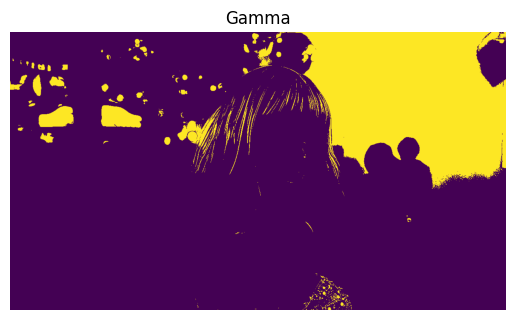

In [5]:
if len(image.shape) == 3:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray_image = image


ret, output_image2 = cv2.threshold(gray_image, 0 , 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(ret)

plt.imshow(output_image2[..., ::-1])
plt.title("Gamma")
plt.axis("off")
plt.show()

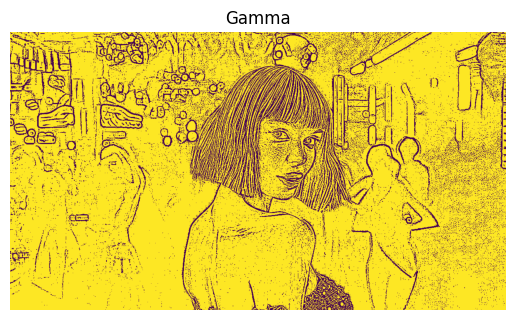

In [6]:
output_image3 = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.imshow(output_image3[..., ::-1])
plt.title("Gamma")
plt.axis("off")
plt.show()

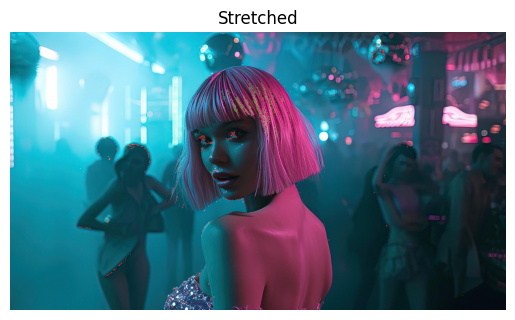

In [7]:
r_min = np.min(image)
r_max = np.max(image)

# 2. Define the target range
s_min, s_max = 0, 255

r_min = np.min(image)
r_max = np.max(image)

stretched = ((r_max - r_min) / (s_max - s_min)) * (image.astype('float32') - r_min) + s_max

stretched = np.uint8(stretched)

plt.imshow(stretched[..., ::-1])
plt.title("Stretched")
plt.axis("off")
plt.show()

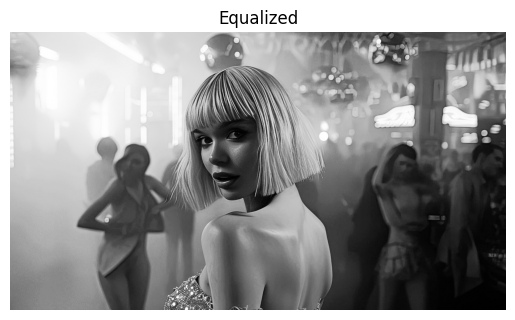

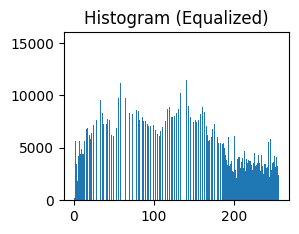

In [8]:
equalized = cv2.equalizeHist(gray_image) # calculate CDF

plt.imshow(equalized, cmap="gray")
plt.title("Equalized")
plt.axis("off")
plt.show()

plt.subplot(2, 2, 4)
plt.hist(equalized.ravel(), 256, range=(0,256))
plt.title('Histogram (Equalized)')

plt.show()

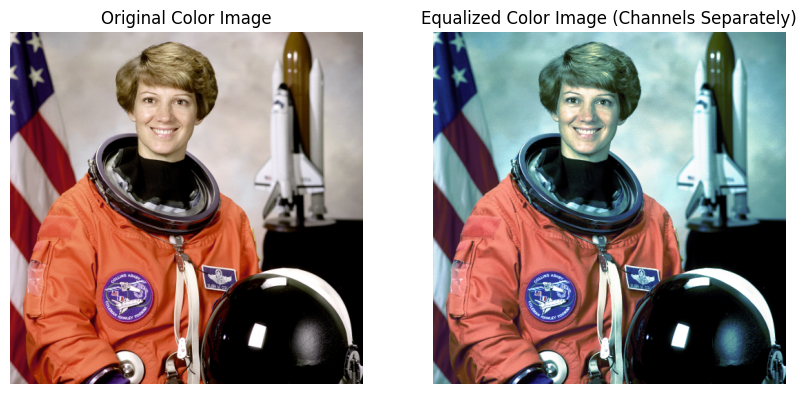

In [9]:
image = cv2.imread("../data/images/astronaut.png")

# Equalization for color image
(b, g, r) = cv2.split(image)

# For each channel
equalized_b = cv2.equalizeHist(b)
equalized_g = cv2.equalizeHist(g)
equalized_r = cv2.equalizeHist(r)

equalized_color_image = cv2.merge([equalized_b,
equalized_g, equalized_r])

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(equalized_color_image, cv2.COLOR_BGR2RGB))
plt.title('Equalized Color Image (Channels Separately)')
plt.axis('off')
plt.show()

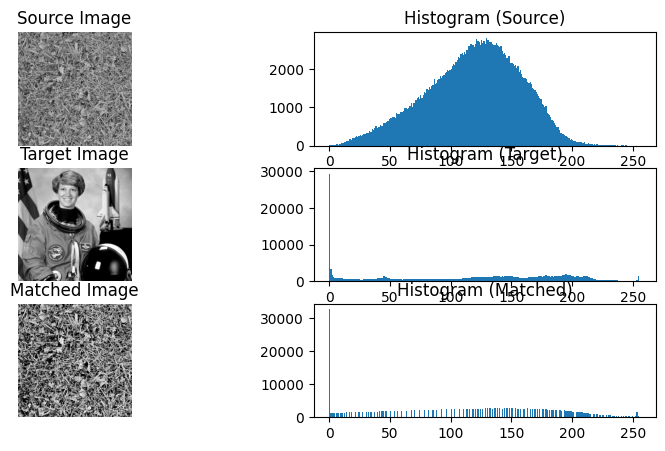

In [10]:
image_source = cv2.imread("../data/images/grass.png", cv2.IMREAD_GRAYSCALE)
image_target = cv2.imread("../data/images/astronaut.png", cv2.IMREAD_GRAYSCALE)

matched_image = exposure.match_histograms(image_source, image_target)

plt.figure(figsize=(15,5))

# Source image and its histogram
plt.subplot(3, 3, 1)
plt.imshow(image_source, cmap='gray')
plt.title('Source Image')
plt.axis('off')
plt.subplot(3, 3, 2)
plt.hist(image_source.ravel(), 256, range=(0,256))
plt.title('Histogram (Source)')
# Target image and its histogram
plt.subplot(3, 3, 4)
plt.imshow(image_target, cmap='gray')
plt.title('Target Image')
plt.axis('off')
plt.subplot(3, 3, 5)
plt.hist(image_target.ravel(), 256, range=(0,256))
plt.title('Histogram (Target)')
# Matched image and its histogram
plt.subplot(3, 3, 7)
plt.imshow(matched_image, cmap='gray')
plt.title('Matched Image')
plt.axis('off')
plt.subplot(3, 3, 8)
plt.hist(matched_image.ravel(), 256, range=(0,256))
plt.title('Histogram (Matched)')
plt.show()